<Axes: xlabel='time'>

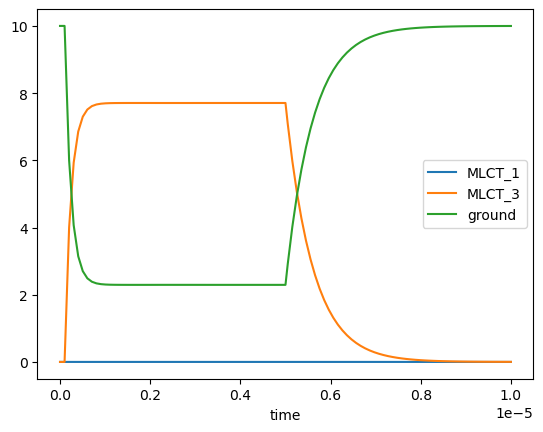

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pint

from jablonski import (
    Simulator,
    SingletState,
    SpectroscopicSystem,
    TripletState,
    initial,
)
from jablonski.simulation import (
    piecewise,
    pulse_excitation,
    spectral_time_resolved_emission,
)
from jablonski.sweeps import sweep_emission_spectra
from jablonski.transitions import (
    Absorption,
    InternalConversion,
    IntersystemCrossing,
    Phosphorescence,
    ReverseIntersystemCrossing,
)

u = pint.get_application_registry()


# Defiene Ruthenium tris(bipyridine)
class Ruthenium(SpectroscopicSystem):
    ground: SingletState = initial(
        0 * u.eV, "singlet", default=10
    )  # Define ground state
    MLCT_3: TripletState = initial(
        2.12 * u.eV, "triplet", default=0
    )  # Triplet MLCT level
    MLCT_1: SingletState = initial(2.74, default=0)  # Singlet MLCT level

    abs = Absorption(
        ground=ground, excited=MLCT_1, rate=5.6e-17 * u.cm**2
    )  # Photon absorption, rate is cross-section
    ph = Phosphorescence(
        ground=ground, excited=MLCT_3, rate=1 / (0.6 * u.us) * 0.04
    )  # Radiative decay from  MLCT_3 to ground
    risc = ReverseIntersystemCrossing(
        source=MLCT_3, target=ground, rate=1 / (0.6 * u.us) * 0.96
    )  # Non radiative decay from  MLCT_3 to ground
    isc = IntersystemCrossing(
        source=MLCT_1, target=MLCT_3, rate=1 / (1 * u.ps) * 0.96
    )  # Non radiative decay from  MLCT_1 to MLCT_3


sim_1 = Simulator(Ruthenium)
pulse_1 = pulse_excitation(
    Ruthenium.abs, height=1e23 / (u.cm**2 * u.s), width=5 * u.us
)  # Pulse in photon flux
result_1 = piecewise(sim_1, events=pulse_1, save_at=np.linspace(0, 10e-6, 100))
result_1.to_dataframe().plot()

In [2]:
# Defiene Osmium Compound
class Osmium(SpectroscopicSystem):
    ground: SingletState = initial(
        0 * u.eV, "singlet", default=0
    )  # Define ground state
    MLCT_3: TripletState = initial(1.7, "triplet", default=0)  # Singlet MLCT level

    ph = Phosphorescence(
        ground=ground, excited=MLCT_3, rate=1 / (50 * u.ns) * 0.004
    )  # Radiative decay from  MLCT_3 to ground
    risc = ReverseIntersystemCrossing(
        source=MLCT_3, target=ground, rate=1 / (50 * u.ns) * 0.996
    )  # Non radiative decay from  MLCT_3 to ground

In [3]:
# Combine both
class Ru_Os(SpectroscopicSystem):
    ru = Ruthenium()
    os = Osmium()

    transfer = InternalConversion(
        high=ru.MLCT_3, low=os.MLCT_3, rate=(2.2e7 + 2e8) / u.s
    )
    back_transfer = InternalConversion(
        high=os.ground, low=ru.ground, rate=(9.1e7 + 1.2e8) / u.s
    )

<Axes: xlabel='time'>

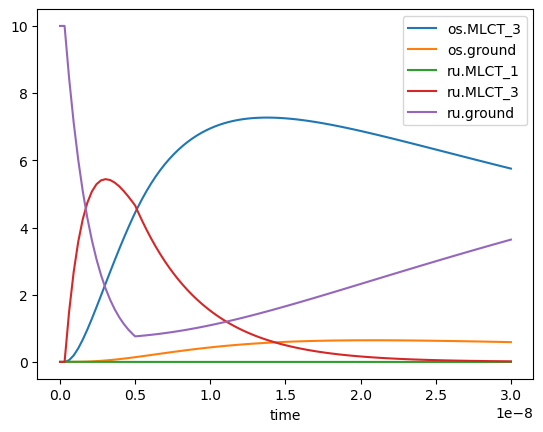

In [17]:
pulse_2 = pulse_excitation(Ru_Os.ru.abs, height=1e25 / (u.cm**2 * u.s), width=5 * u.ns)
sim_2 = Simulator(Ru_Os)
result_2 = piecewise(sim_2, events=pulse_2, save_at=np.linspace(0, 30e-9, 100))
result_2.to_dataframe().plot()

c:\Users\olive\dyscolab\u2602\.pixi\envs\default\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


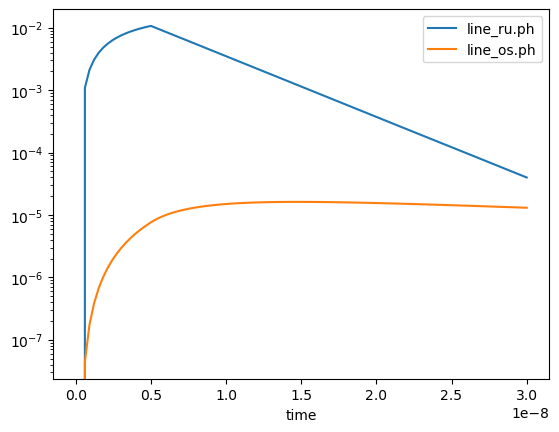

In [5]:
spectral = spectral_time_resolved_emission(
    Ru_Os, excitation=pulse_2, save_at=np.linspace(0, 30e-9, 100)
)  # Time resolved emission
spectral.to_dataframe().plot()
spectral.attrs  # Print dict with energy associated with each line
plt.yscale("log")

c:\Users\olive\dyscolab\u2602\.pixi\envs\default\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


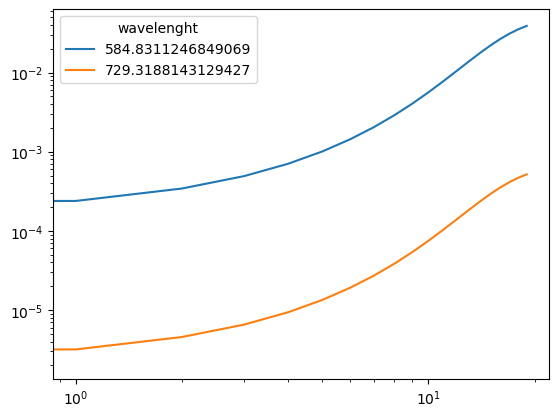

In [14]:
steady = sweep_emission_spectra(
    Ru_Os,
    excitation_transition=Ru_Os.ru.abs,
    heights=np.logspace(21, 24, 20) / (u.cm**2 * u.s),
)  # Sweep steady state emission spectra
steady.to_dataframe().T.plot()
plt.xscale("log")
plt.yscale("log")

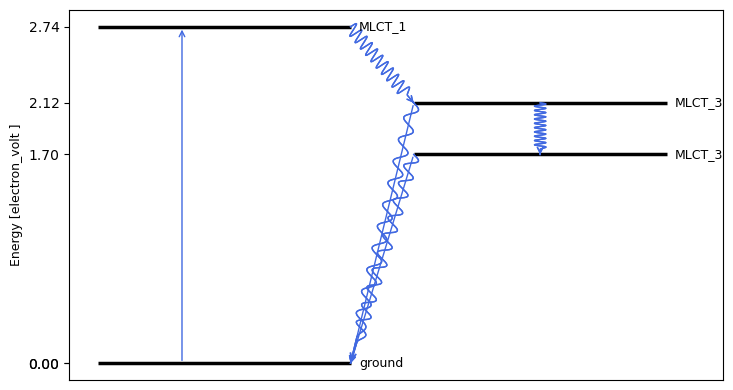

In [ ]:
# Jablonski diagram
from jablonski.plots import jablonski_diagram

fig, ax = jablonski_diagram(Ru_Os, figsize=(7.5, 4), fontsize=9)